<a href="https://colab.research.google.com/github/Raharijao/churnguard-data622/blob/main/eda_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Bank Customer Churn Prediction.csv to Bank Customer Churn Prediction.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [10]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')

df.shape
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df.drop(columns=['customer_id'], inplace=True)

In [13]:
df['churn'].value_counts()
df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.7963
1,0.2037


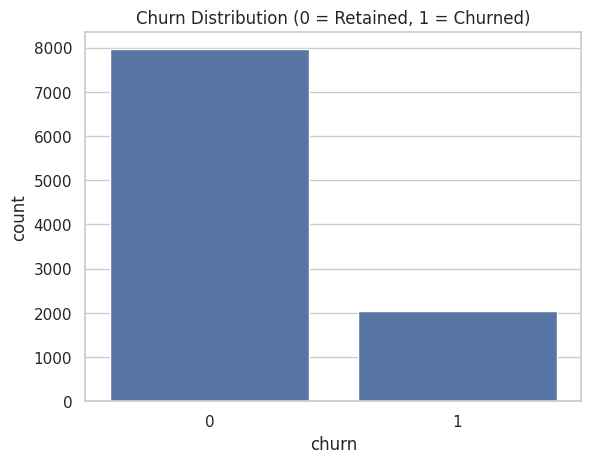

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=df)
plt.title('Churn Distribution (0 = Retained, 1 = Churned)')
plt.show()

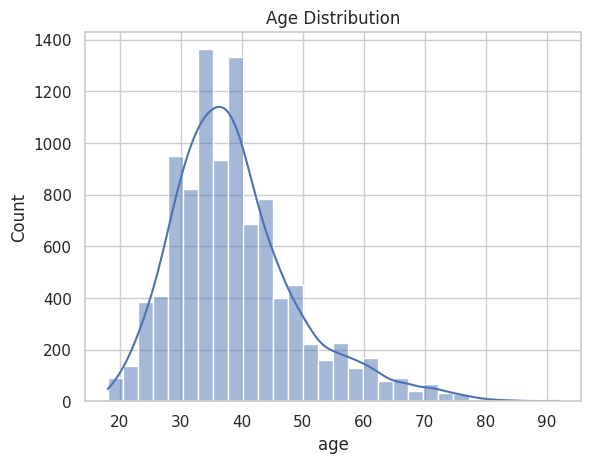

In [15]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

Age is a Strong Factor
Retained: 37.4
Churned: 44.8

Customers who churn are significantly older

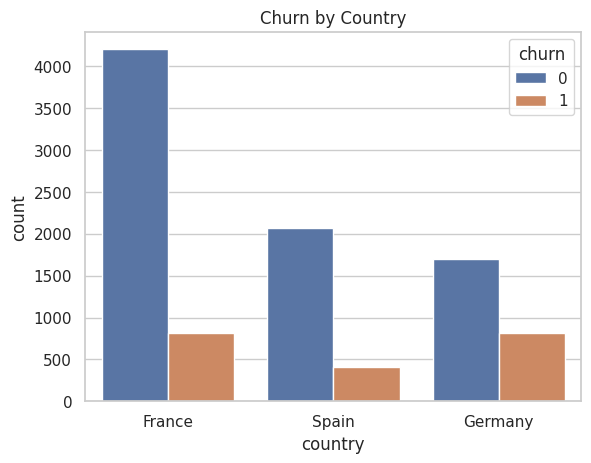

In [16]:
sns.countplot(x='country', hue='churn', data=df)
plt.title('Churn by Country')
plt.show()

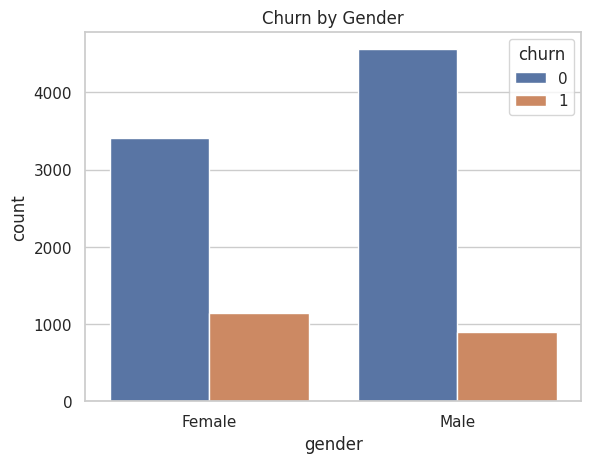

In [17]:
sns.countplot(x='gender', hue='churn', data=df)
plt.title('Churn by Gender')
plt.show()

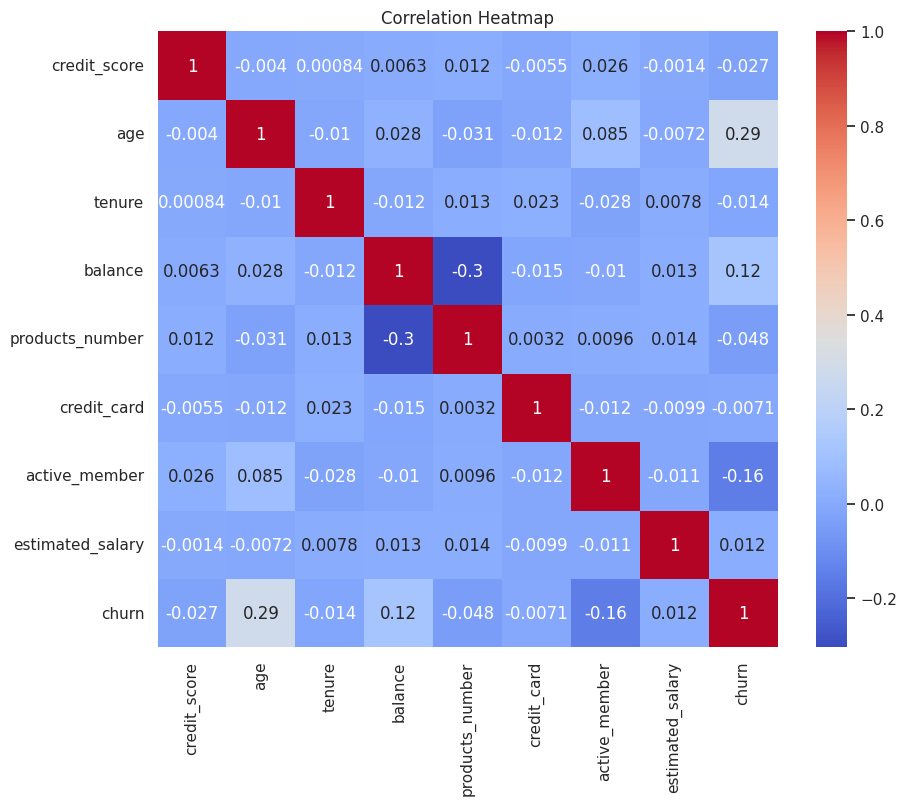

In [18]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
df.groupby('churn').mean(numeric_only=True)

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
churn,,,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,0.707146,0.554565,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531


**Prime Insights**

1. Age is a Strong Factor
Retained: 37.4
Churned: 44.8

Customers who churn are significantly older

2. Balance is Higher for Churned Customers
Retained: ~72,745
Churned: ~91,108

Customers with higher balances are more likely to churn
(This is a very strong business insight)

3. Active Membership Matters A LOT
Retained: 55.5% active
Churned: 36.1% active

Inactive customers are much more likely to churn

4. Products Slightly Lower for Churned
Retained: 1.54
Churned: 1.47

Customers with fewer products tend to churn more

5. Credit Score (Weak Effect)
Small difference (~652 vs 645)

Not a strong predictor alone

6. Tenure & Salary (Not Very Important)
Very similar values

Likely weaker features

**Statistical Insights**:

Customers who churn tend to be older on average, suggesting age is a significant factor in churn behavior.
Churned customers have higher average account balances, indicating that high-value customers may be at greater risk of leaving.
Active membership strongly impacts retention, as churned customers are significantly less likely to be active members.
Customers with fewer banking products show slightly higher churn rates, suggesting lower engagement contributes to attrition.
Credit score, tenure, and estimated salary show minimal differences, indicating they may be weaker predictors of churn.